In [1]:
# Autorelaode all modules when they change
%load_ext autoreload
%autoreload 2

# Establishing TC max wind speed distributions

Here, we wantt to generate sythetic cyclone tracks. For this we load and preprocess the ATCF archive. We then use a MCMC to create artifical strom tracks 

In [ ]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append('../src')

from preprocessing.tropical_cyclone import aggregate_tc_data


In [ ]:
# Data downloader that aggregates all storm data neccesarry for the probabilistic model
#TODO: maybe move this function to a better place
aggregate_tc_data(np.arange(1900,2021), basin='al')

Fetching file lists for 50 year(s)...
Found 435 file(s) in total. Starting download...


Downloading: 100%|██████████| 435/435 [03:17<00:00,  2.20file/s]


All files downloaded successfully.


In [ ]:
# In the code base we have some helper functions to extract all 
# track data and generte synthetic cyclone genesis points and assign genesis intensity to them
from probabilistic import load_historical_tracks, generate_synthetic_tc_origin, assign_genesis_intensity

track_data, failed_files = load_historical_tracks("/Users/wirths/Documents/Private/NatCat/data/raw")
print(f"Loaded {len(track_data)} tracks.")

In [13]:
# Using a gaussian kde we can now generate synthetic genesis points.
tc_origin, historic_origin, kde = generate_synthetic_tc_origin(track_data, 100)
tc_origin.head()

,storm_id,latitude,longitude
0,SYN_0,25.302378,-54.270804
1,SYN_1,13.254022,-17.051656
2,SYN_2,24.344148,-58.925772
3,SYN_3,19.562408,-105.318522
4,SYN_4,29.259570,-49.272305


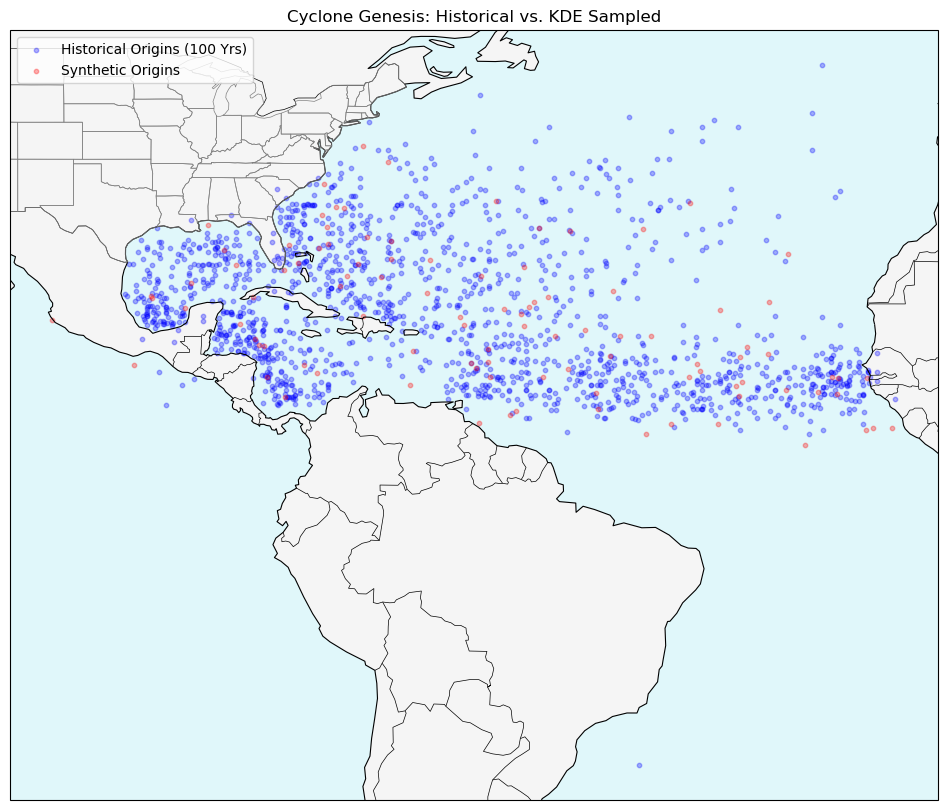

In [ ]:
# Quickly plitting the historical and synthetic genesis points to see how well they match up

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig = plt.figure(figsize=(14, 10))
ax = plt.axes(projection=ccrs.PlateCarree())
        
# Add Map Features
ax.add_feature(cfeature.LAND, facecolor='#f5f5f5')
ax.add_feature(cfeature.OCEAN, facecolor='#e0f7fa')
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.STATES, linewidth=0.5, edgecolor='gray')
#ax.set_extent(ax_extend, crs=ccrs.PlateCarree())
# Plot historical in blue
ax.scatter(historic_origin['longitude'], historic_origin['latitude'], 
            c='blue', alpha=0.3, s=10, label='Historical Origins (100 Yrs)')

# Plot synthetic in red
ax.scatter(tc_origin['longitude'], tc_origin['latitude'], 
            c='red', alpha=0.3, s=10, label='Synthetic Origins')

plt.title("Cyclone Genesis: Historical vs. KDE Sampled")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Inital wind speed and strom radius is assignes randomly taking the historical values via KNN 
synt_final = assign_genesis_intensity(tc_origin, historic_origin)
synt_final.head()

### Full synthetic cyclone generation



55 file(s) failed to load.
Loaded 1495 tracks.
Stacking 1495 storm tracks...
Building fast transition lookup dictionary...
Model fitted. Ready to generate synthetic storms.
Poisson sampling: 117 storms across 10 synthetic years.
Generating tracks for 117 synthetic origins...
Simulation complete! Generated 117 synthetic storms (8007 track points).


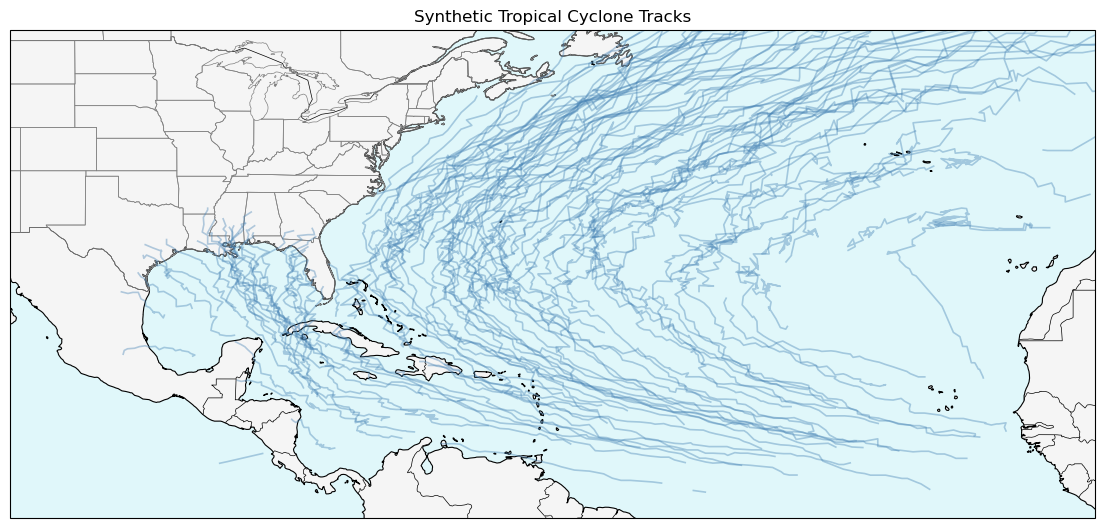

In [17]:
# We have everything within the SyntheticTCCatalog where we can also set all parameters 
# We then just need to define where the database is located and how many stroms or years
# (using poisson distribution of stroms per year) to generate storm tracks and then we can also plot them.
from probabilistic import SyntheticTCCatalog

model = SyntheticTCCatalog(basin='al', grid_size=2.0, max_hours=360)
model.fit("/Users/wirths/Documents/Private/NatCat/data/raw")
catalog = model.generate(n_years=10)
model.plot_tracks(color="steelblue")
